# Tutorial 05 - BME with Interval (Soft) Data

**Package:** stamps_v3  
**MATLAB equivalent:** `BMEINTLIBtutorial.m`  
**Dataset:** Falmagne interval dataset (`IntervalData.txt`)

---

## Learning objectives

1. Load and explore the Falmagne **interval soft data** dataset.
2. Encode interval observations as **uniform soft PDFs** with `probaUniform`.
3. Run **BME posterior-moments** estimation with `BMEPosteriorMoments`.
4. Compare the BME result to the ordinary kriging estimate from Tutorial 04.

### What is interval (soft) data?

Instead of knowing the exact sand content at a location, we know only that it falls within an interval $[z^{lo}, z^{up}]$.  BME encodes this as a **uniform probability density** over the interval.

$$f(z) = \begin{cases} \frac{1}{z^{up} - z^{lo}} & z^{lo} \le z \le z^{up} \\
         0 & \text{otherwise} \end{cases}$$

This is a *soft* measurement: less informative than a precise value but more informative than knowing nothing.


In [1]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt


from stamps.bme.softconverter import probaUniform, proba2stat
from stamps.bme.BMEprobaEstimations import BMEPosteriorMoments

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
DATA_DIR = os.path.join(os.getcwd(), 'data')

# Load hard data and grid from Tutorial 01
with open(os.path.join(DATA_DIR, 'tutorial01_data.pkl'), 'rb') as f:
    d1 = pickle.load(f)
ch   = d1['ch']
sand = d1['sand']
ck   = d1['ck']
n_e  = d1['n_e']
n_n  = d1['n_n']

# Load covariance model from Tutorial 03
with open(os.path.join(DATA_DIR, 'tutorial03_cov.pkl'), 'rb') as f:
    cov = pickle.load(f)
covmodel = cov['sand_covmodel']
covparam = cov['sand_covparam']

# Load kriging results from Tutorial 04 (for comparison)
krig_path = os.path.join(DATA_DIR, 'tutorial04_krig.pkl')
krig_available = os.path.exists(krig_path)
if krig_available:
    with open(krig_path, 'rb') as f:
        krig = pickle.load(f)
    zk_ok_mean = krig['zk_ok_mean']
    zk_ok_var  = krig['zk_ok_var']
    print('Kriging results loaded.')

print('Hard data:', ch.shape, '  Grid:', ck.shape)


Kriging results loaded.
Hard data: (118, 2)   Grid: (323, 2)


## 1. Load the interval dataset

The `IntervalData.txt` file contains 323 soil samples where the sand, silt and clay contents are given as intervals of width 20% (e.g., sand in [20%, 40%]).


In [2]:
# Read interval data (skip % comment lines)
interval_path = os.path.join(DATA_DIR, 'IntervalData.txt')
rows = []
with open(interval_path) as fh:
    for line in fh:
        s = line.strip()
        if s and not s.startswith('%'):
            rows.append([float(v) for v in s.split()])

data = np.array(rows)   # (323, 8)
cs      = data[:, :2]   # easting, northing
s_lo    = data[:, 2]    # sand lower bound (%)
s_hi    = data[:, 3]    # sand upper bound (%)

print(f'Interval soft data: {cs.shape[0]} locations')
print(f'Sand interval range: [{s_lo.min():.0f}, {s_hi.max():.0f}] %')
print(f'Mean interval width: {np.mean(s_hi - s_lo):.1f} %')

# Easting / Northing extents
e_range = cs[:, 0].min(), cs[:, 0].max()
n_range = cs[:, 1].min(), cs[:, 1].max()
print(f'Easting : {e_range[0]:.0f} -- {e_range[1]:.0f} m')
print(f'Northing: {n_range[0]:.0f} -- {n_range[1]:.0f} m')


Interval soft data: 323 locations
Sand interval range: [0, 60] %
Mean interval width: 20.0 %
Easting : 177275 -- 193337 m
Northing: 89270 -- 107332 m


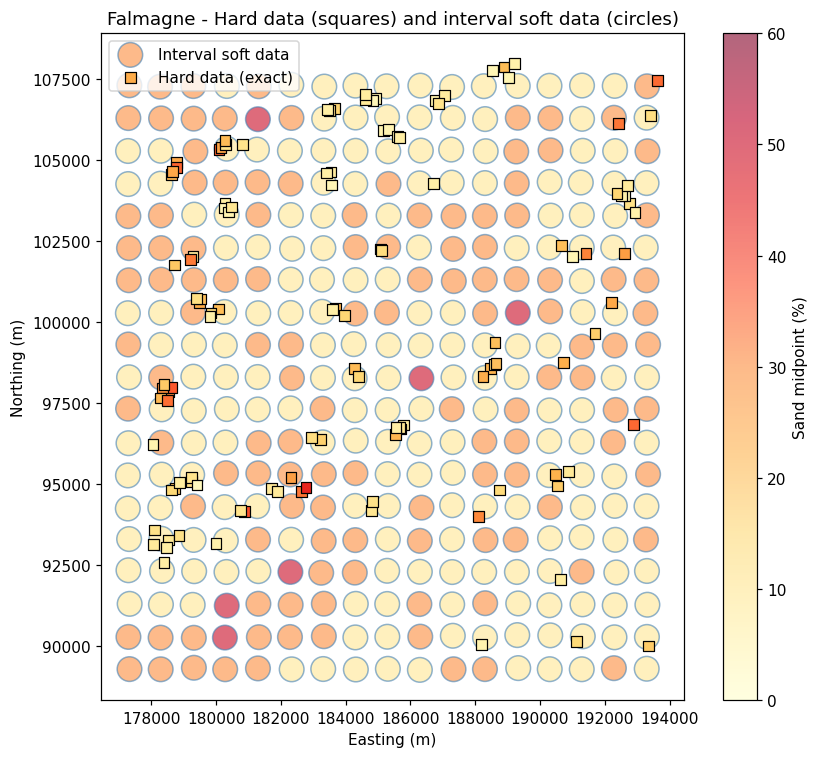

In [3]:
# Visualise hard data and soft data locations
mid_sand = 0.5 * (s_lo + s_hi)  # interval midpoints for colour coding

fig, ax = plt.subplots(figsize=(8, 7))
# Soft data: circles sized by interval width
widths = s_hi - s_lo
sc_soft = ax.scatter(cs[:, 0], cs[:, 1],
                     c=mid_sand, cmap='YlOrRd', vmin=0, vmax=60,
                     s=100 + 8 * widths, alpha=0.6,
                     edgecolors='steelblue', linewidths=1.0, label='Interval soft data')
# Hard data: filled squares
sc_hard = ax.scatter(ch[:, 0], ch[:, 1],
                     c=sand, cmap='YlOrRd', vmin=0, vmax=60,
                     marker='s', s=50, edgecolors='k', linewidths=0.8,
                     label='Hard data (exact)')
plt.colorbar(sc_soft, ax=ax, label='Sand midpoint (%)')
ax.set_title('Falmagne - Hard data (squares) and interval soft data (circles)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()


## 2. Encode intervals as uniform soft PDFs

`probaUniform` converts lower/upper bounds into the standard stamps soft-data format:

```python
zs = probaUniform(zlow, zup)
# Returns: [softpdftype=2, nl, limi, probdens]
#   softpdftype : 2 = piecewise-linear PDF
#   nl          : (ns, 1) number of limit points per location
#   limi        : (ns, 2) lower and upper bounds
#   probdens    : (ns, 2) constant probability density
```


In [4]:
# Encode sand intervals as uniform soft PDFs
zs_soft = probaUniform(s_lo, s_hi)
softpdftype, nl, limi, probdens = zs_soft

# Convert batch format → list of per-location entries expected by BMEPosteriorMoments
# Each entry: (softpdftype, nl_i [1×1], limi_i [1×nl_i], probdens_i [1×nl_i])
zs_list = [
    (softpdftype, nl[i:i+1, :], limi[i:i+1, :], probdens[i:i+1, :])
    for i in range(nl.shape[0])
]

print(f'softpdftype : {softpdftype}')
print(f'nl shape    : {nl.shape}  (first 5: {nl[:5, 0]})')
print(f'limi shape  : {limi.shape}')
print(f'probdens shape: {probdens.shape}')
print('\nFirst 5 soft data records:')
for i in range(5):
    lo, hi = limi[i]
    pd = probdens[i, 0]
    print(f'  [{lo:.1f}, {hi:.1f}]  -> pdf = {pd:.4f}')


softpdftype : 2
nl shape    : (323, 1)  (first 5: [2 2 2 2 2])
limi shape  : (323, 2)
probdens shape: (323, 2)

First 5 soft data records:
  [20.0, 40.0]  -> pdf = 0.0500
  [20.0, 40.0]  -> pdf = 0.0500
  [0.0, 20.0]  -> pdf = 0.0500
  [0.0, 20.0]  -> pdf = 0.0500
  [0.0, 20.0]  -> pdf = 0.0500


Soft data summary (sand %)
  Mean of soft means : 18.30%
  Mean of soft vars  : 33.33
  Hard data mean     : 15.18%
  Hard data var      : 90.49


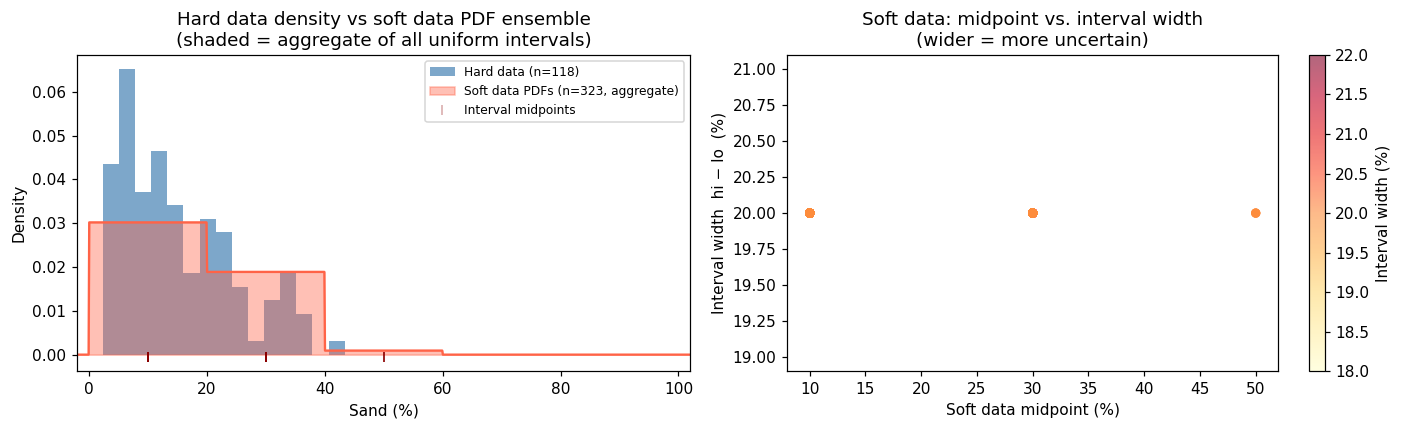


Interval width stats: min=20%  mean=20.0%  max=20%


In [5]:
# Compute soft data summary statistics
soft_mean, soft_var = proba2stat(softpdftype, nl, limi, probdens)

print('Soft data summary (sand %)')
print(f'  Mean of soft means : {np.mean(soft_mean):.2f}%')
print(f'  Mean of soft vars  : {np.mean(soft_var):.2f}')
print(f'  Hard data mean     : {np.mean(sand):.2f}%')
print(f'  Hard data var      : {np.var(sand):.2f}')

# ── Panel 1: aggregate soft-data PDF vs hard-data distribution ─────────────
# For each uniform interval [s_lo_i, s_hi_i] the PDF is  1/(hi-lo) on [lo,hi].
# Summing all N individual PDFs and dividing by N gives the average ensemble
# density — a proper representation of the collective information in the soft
# data, rather than concentrating all weight at the interval midpoints.
z_grid = np.linspace(-2, 102, 1000)
soft_agg = np.zeros_like(z_grid)
for lo, hi in zip(s_lo, s_hi):
    w = hi - lo
    if w > 0:
        mask = (z_grid >= lo) & (z_grid <= hi)
        soft_agg[mask] += 1.0 / w
soft_agg /= len(s_lo)           # average per-sample density

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Hard data: density histogram
axes[0].hist(sand, bins=15, density=True, alpha=0.70,
             color='steelblue', label=f'Hard data (n={len(sand)})')

# Soft data: aggregate uniform PDF as a shaded area + line
axes[0].fill_between(z_grid, soft_agg, alpha=0.40, color='tomato',
                     label=f'Soft data PDFs (n={len(s_lo)}, aggregate)')
axes[0].plot(z_grid, soft_agg, color='tomato', lw=1.5)

# Rug of midpoints along the x-axis baseline for reference
axes[0].plot(soft_mean, np.zeros(len(soft_mean)) - 0.0005, '|',
             color='darkred', ms=6, alpha=0.35, label='Interval midpoints')

axes[0].set_xlim(-2, 102)
axes[0].set_xlabel('Sand (%)')
axes[0].set_ylabel('Density')
axes[0].set_title('Hard data density vs soft data PDF ensemble\n'
                  '(shaded = aggregate of all uniform intervals)')
axes[0].legend(fontsize=8)

# ── Panel 2: interval width (uncertainty) vs midpoint (value) ──────────────
widths = s_hi - s_lo
sc = axes[1].scatter(soft_mean, widths, c=widths, cmap='YlOrRd',
                     alpha=0.6, s=25)
plt.colorbar(sc, ax=axes[1], label='Interval width (%)')
axes[1].set_xlabel('Soft data midpoint (%)')
axes[1].set_ylabel('Interval width  hi − lo  (%)')
axes[1].set_title('Soft data: midpoint vs. interval width\n'
                  '(wider = more uncertain)')

plt.tight_layout()
plt.show()

print(f'\nInterval width stats: min={widths.min():.0f}%  mean={widths.mean():.1f}%'
      f'  max={widths.max():.0f}%')


## 3. BME posterior moments estimation

We now run `BMEPosteriorMoments` combining:

- **Hard data** at 118 precise locations (`ch`, `zh`).
- **Interval soft data** at 323 additional locations (`cs`, `zs`).
- **Prior covariance** model (nugget + spherical) fitted in Tutorial 03.

The posterior BME estimate at each grid node is computed as:

$$\hat{z}^{BME}_k = \int z \cdot f_k(z | \text{data}) \, dz$$

where $f_k$ is the posterior PDF at node $k$, updated from the prior using Bayes' theorem.

### How to read the maps

Each map produced by `plot_map` may include two data overlays on top of the colour field:

| Symbol | What it represents |
|---|---|
| **Filled squares** (colour-matched) | Hard data locations — 118 exact sand measurements |
| **Open steelblue circles** | Interval soft-data locations — marks *where* interval observations exist, **not** their magnitude |

The open circles simply show the **spatial coverage** of the soft dataset.  Their colour and size carry no quantitative information on those maps.

> **Colormap note.**  Maps use `YlOrRd` (pale yellow → dark red).  Low sand values
> (0–15 %) appear **pale yellow**, not white.  If a boundary area looks pale, it
> genuinely has low sand content — it is not a rendering artefact or missing data.

> **Note on boundary colours.** The south and south-west region of the Falmagne
> study area genuinely has **low sand content** — the nearest hard data points
> there record only 5–8 % sand, 2–4 km from the boundary nodes.  So pale colours
> near the south boundary are **physically correct**, not estimation artefacts.
> The only setting that produces *artificially* zero boundary values is
> `order=np.nan` (zero-mean prior, demonstrated as Plot A in Section 5).


In [6]:
# BME options
nhmax = 12    # max hard data neighbours
nsmax = 8     # max soft data neighbours (balances accuracy and computation time)
dmax  = 10_000.0  # 10 km search radius

# Prior mean:  order=0  →  constant mean = average of ALL data (hard + soft).
#   At estimation nodes with little nearby data (e.g. map boundaries) the
#   estimate reverts to this constant, which prevents unphysical collapse to 0.
# ⚠  Do NOT use order=np.nan here: that sets a ZERO prior mean, causing the
#   estimate to approach 0 wherever data is sparse — demonstrably wrong for
#   sand content.  The zero-prior case is shown as Plot A in Section 5 below.
order = 0

# BMEoptions: 'inflate' strategy widens incompatible intervals before QMC
# so the integration remains numerically stable. This is the default.
# For all-uniform-interval data, the Prior IS mode (sampling from the
# conditional prior N(mu_{s|h}, Sigma_{s|h}) with binary weights) is activated
# automatically, giving efficient QMC with >=95% per-dimension acceptance.
from stamps.bme.BMEoptions import BMEoptions
bme_opts = BMEoptions()  # uses defaults (outlier_handling='inflate')

# Run BME posterior moments
print('Running BMEPosteriorMoments with interval soft data...')
print(f'  nhmax={nhmax}, nsmax={nsmax}, dmax={dmax:.0f} m')
print('  This may take a minute...')

result = BMEPosteriorMoments(
    ck,
    ch    = ch,
    cs    = cs,
    zh    = sand.reshape(-1, 1),
    zs    = zs_list,                 # list of per-location soft data entries
    covmodel = covmodel,
    covparam = covparam,
    order    = order,
    nhmax    = nhmax,
    nsmax    = nsmax,
    dmax     = np.array([[dmax]]),
    options  = bme_opts,
)

zk_bme_mean = result[:, 0]
zk_bme_var  = result[:, 1]
print(f'BME estimated {np.sum(~np.isnan(zk_bme_mean))} / {len(ck)} nodes')
print(f'  Mean estimate : {np.nanmean(zk_bme_mean):.2f}%')
print(f'  Mean variance : {np.nanmean(zk_bme_var):.4f}')


Running BMEPosteriorMoments with interval soft data...
  nhmax=12, nsmax=8, dmax=10000 m
  This may take a minute...
preparing...done
[STARBME] BME estimation: nk=323, nh=118, ns=323, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


323 / 323
[STARBME] BME estimation completed in 3.7s (0.011s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.07353, max=0.1935; rel_err  median=0.47%, max=1.11% (323 of 323 points had QMC error info)
BME estimated 323 / 323 nodes
  Mean estimate : 16.45%
  Mean variance : 47.1317


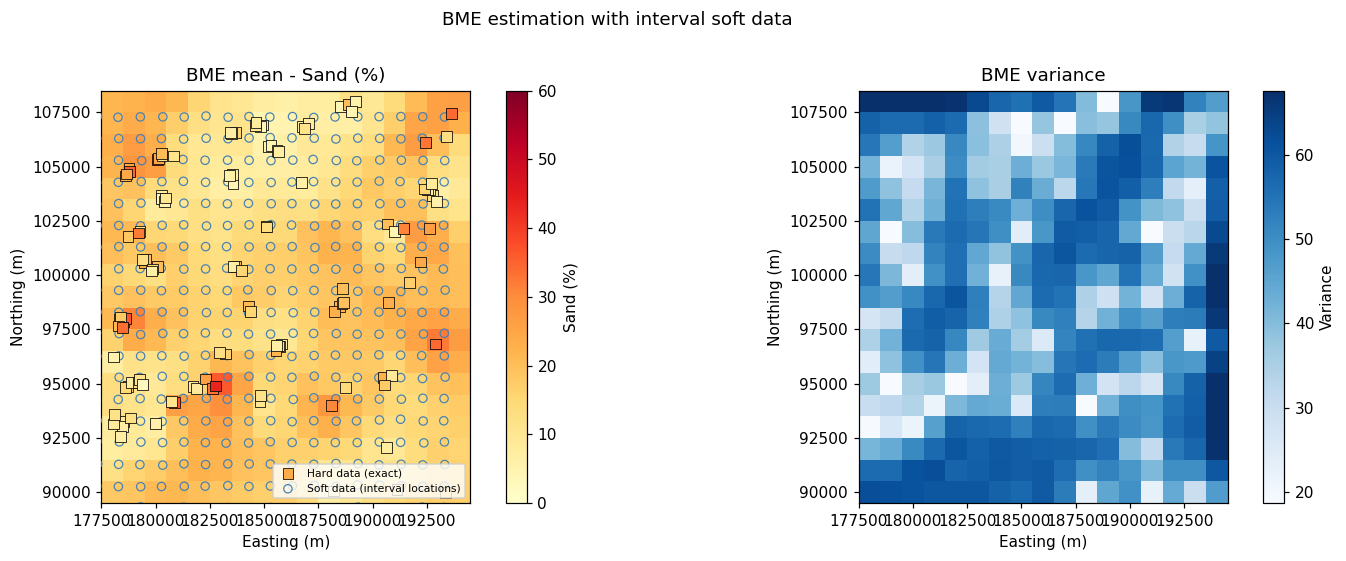

In [7]:
def plot_map(ax, ck, zk, title, n_e, n_n, cmap='YlOrRd',
             ch_data=None, data_vals=None, cs_data=None,
             vmin=None, vmax=None, cbar_label='', show_legend=True):
    """Render a regular-grid estimation result as a pcolormesh.

    Parameters
    ----------
    cmap : str, default ``'YlOrRd'``
        Colormap.  ``YlOrRd`` is preferred over ``hot_r`` because its low end
        maps to pale **yellow** rather than pure white, so near-zero values
        (e.g. 5–10 % sand) remain clearly visible instead of blending into
        the white background.
    ch_data : array, optional
        Hard-data coordinates — plotted as filled black-edged squares.
    cs_data : array, optional
        Soft-data (interval) coordinates — plotted as open steelblue circles.
        These mark the locations of interval observations.  They are drawn
        to show the spatial coverage of the soft-data dataset, NOT their
        estimated value.  Circle size and colour carry no extra information.
    show_legend : bool, default True
        Whether to draw a legend when overlays are present.
    """
    eu = np.unique(ck[:, 0])
    nu = np.unique(ck[:, 1])
    Z  = zk.reshape(n_n, n_e)
    vm = vmin if vmin is not None else np.nanpercentile(zk, 2)
    vx = vmax if vmax is not None else np.nanpercentile(zk, 98)
    # Build cell-edge coordinates (one extra point per dimension) so that
    # pcolormesh(shading='flat') fills the entire domain without leaving a
    # half-cell gap at the borders (the artifact seen with shading='nearest').
    dx = float(eu[1] - eu[0]) if len(eu) > 1 else 1.0
    dy = float(nu[1] - nu[0]) if len(nu) > 1 else 1.0
    eu_edges = np.concatenate([[eu[0] - dx / 2], eu + dx / 2])
    nu_edges = np.concatenate([[nu[0] - dy / 2], nu + dy / 2])
    im = ax.pcolormesh(eu_edges, nu_edges, Z, cmap=cmap, vmin=vm, vmax=vx, shading='flat')
    plt.colorbar(im, ax=ax, label=cbar_label)
    has_overlay = False
    if ch_data is not None and data_vals is not None:
        ax.scatter(ch_data[:, 0], ch_data[:, 1], c=data_vals, cmap=cmap,
                   vmin=vm, vmax=vx, edgecolors='k', lw=0.5, s=50,
                   marker='s', zorder=4, label='Hard data (exact)')
        has_overlay = True
    if cs_data is not None:
        # Open circles = interval soft-data locations.
        # Their position shows spatial coverage; circle colour/size has no meaning here.
        ax.scatter(cs_data[:, 0], cs_data[:, 1],
                   facecolors='none', edgecolors='steelblue',
                   s=30, lw=0.8, zorder=3, label='Soft data (interval locations)')
        has_overlay = True
    if has_overlay and show_legend:
        ax.legend(loc='lower right', fontsize=7, framealpha=0.8)
    # Lock axis limits to the grid cell edges so that scatter overlays
    # (e.g. soft-data circles that lie outside the estimation grid) do NOT
    # cause matplotlib to auto-expand the view beyond the pcolormesh domain.
    # Without this, any cs_data point outside ck produces blank white strips
    # along the bottom / left boundaries and inconsistent axis ranges across
    # subplots.
    ax.set_xlim(eu_edges[0], eu_edges[-1])
    ax.set_ylim(nu_edges[0], nu_edges[-1])
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')

vlo, vhi = 0.0, 60.0
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_map(axes[0], ck, zk_bme_mean, 'BME mean - Sand (%)', n_e, n_n,
         ch_data=ch, data_vals=sand, cs_data=cs,
         vmin=vlo, vmax=vhi, cbar_label='Sand (%)')
plot_map(axes[1], ck, zk_bme_var,  'BME variance', n_e, n_n,
         cmap='Blues', cbar_label='Variance')
plt.suptitle('BME estimation with interval soft data', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()



## 4. BME vs. Ordinary Kriging

Ordinary kriging ignores the interval soft data entirely (since it is not a hard observation).  BME incorporates the soft data via its probabilistic framework, generally reducing the estimation variance in regions covered by the soft data.


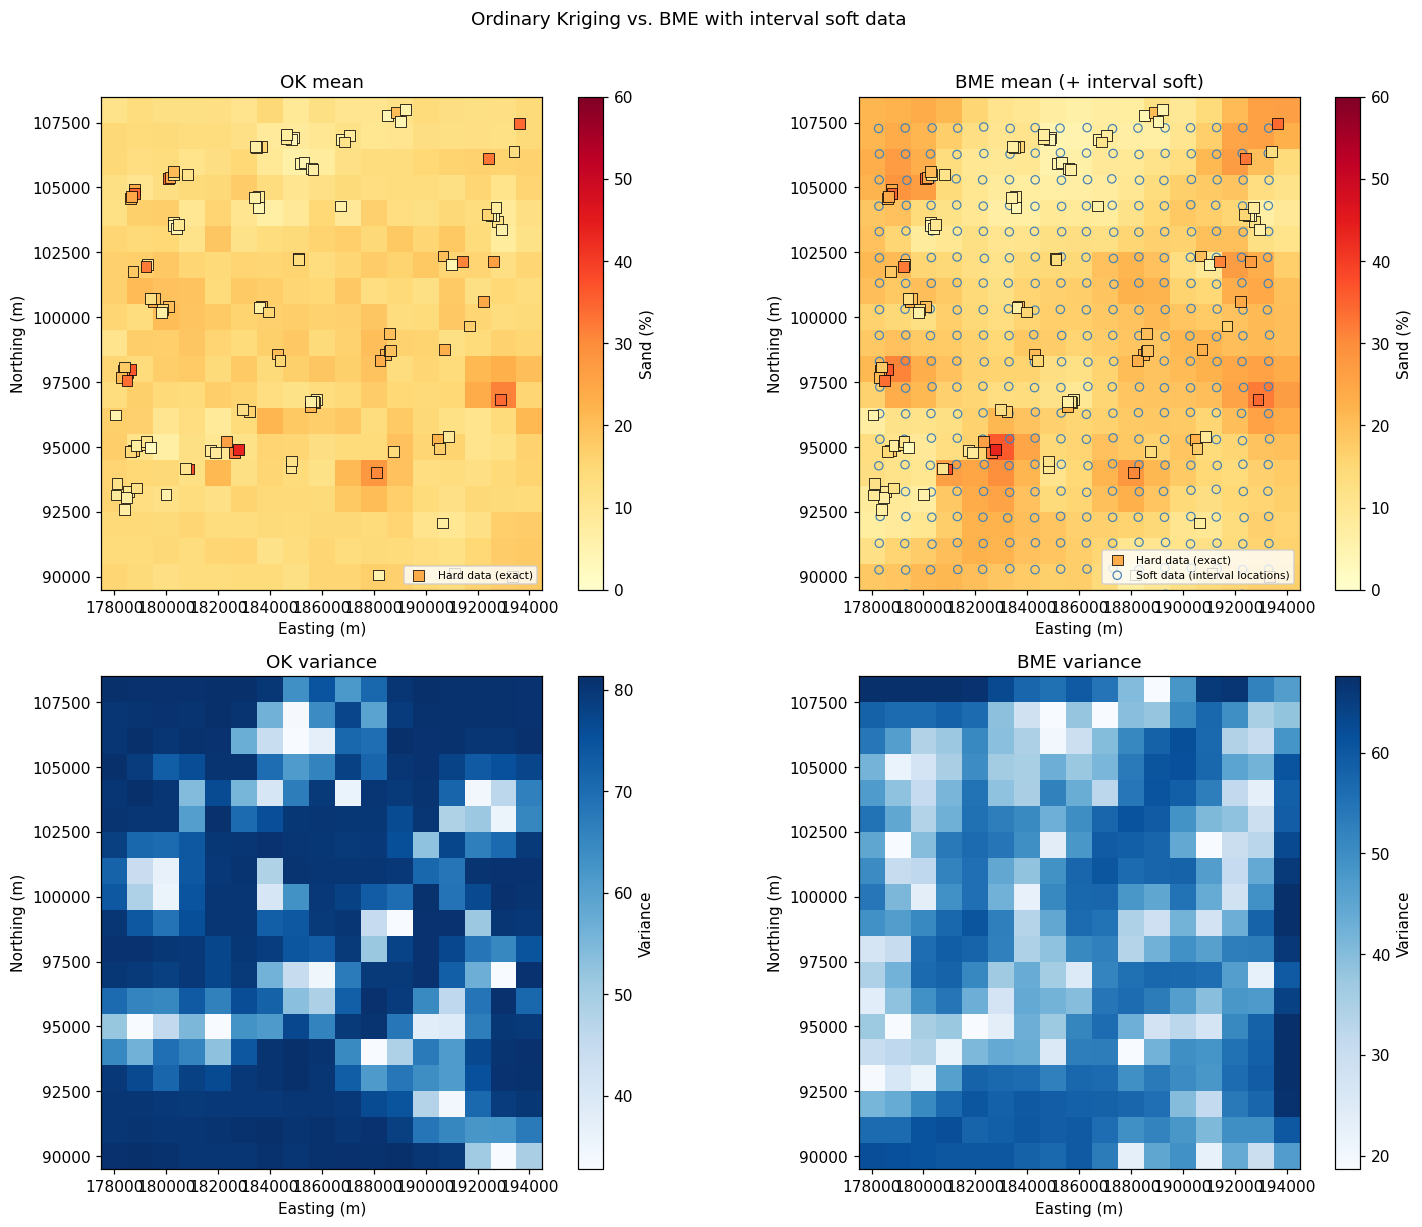

Mean OK variance  : 71.3872
Mean BME variance : 47.1317
Variance reduction: 34.0% (due to soft data)


In [8]:
if krig_available:
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    vlo, vhi = 0.0, 60.0
    plot_map(axes[0, 0], ck, zk_ok_mean, 'OK mean', n_e, n_n,
             ch_data=ch, data_vals=sand,
             vmin=vlo, vmax=vhi, cbar_label='Sand (%)')
    plot_map(axes[0, 1], ck, zk_bme_mean, 'BME mean (+ interval soft)', n_e, n_n,
             ch_data=ch, data_vals=sand, cs_data=cs,
             vmin=vlo, vmax=vhi, cbar_label='Sand (%)')
    plot_map(axes[1, 0], ck, zk_ok_var,  'OK variance', n_e, n_n,
             cmap='Blues', cbar_label='Variance')
    plot_map(axes[1, 1], ck, zk_bme_var, 'BME variance', n_e, n_n,
             cmap='Blues', cbar_label='Variance')
    plt.suptitle('Ordinary Kriging vs. BME with interval soft data', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

    # Quantitative comparison
    delta_var = np.nanmean(zk_ok_var) - np.nanmean(zk_bme_var)
    pct_reduction = 100 * delta_var / np.nanmean(zk_ok_var)
    print(f'Mean OK variance  : {np.nanmean(zk_ok_var):.4f}')
    print(f'Mean BME variance : {np.nanmean(zk_bme_var):.4f}')
    print(f'Variance reduction: {pct_reduction:.1f}% (due to soft data)')
else:
    print('Kriging results not available. Run Tutorial 04 first to compare.')


## 5. The Prior Mean and the `order` Parameter

### 5.1 What is the prior mean?

BME estimation is built on Bayes' theorem.  Before assimilating any data, the field is assumed to follow a multivariate Gaussian with a **prior mean** μ.  In data-sparse regions, the BME estimate reverts toward this prior mean.  Choosing it well is therefore critical for map quality at the boundaries.

### 5.2 How to set `order` in `BMEPosteriorMoments`

The `order` argument is the single knob that controls the prior mean:

```python
BMEPosteriorMoments(..., order=<VALUE>, ...)
```

There are **three distinct usage modes**:

| `order` value | Prior mean | When to use |
|---|---|---|
| `np.nan` | **Zero** everywhere | Only for *residuals / anomalies* with a true zero mean.  Estimates collapse to 0 in data-void areas — **usually wrong for raw measurements.** |
| `0` (integer) | **Global mean** = average of hard data + expected values of soft data | Reasonable for stationary fields.  ⚠️ Biased upward when soft midpoints differ from hard data mean. |
| NumPy array `(nk+nh+ns, 1)` | **Location-specific** value at every node/site | Most flexible.  Use `BMEpriorMean(...)` to build this array. |

> **Quick rule of thumb:**  
> Start with `order=0`.  If soft data midpoints differ noticeably from the hard data mean (here: 18% vs 15%), use `method='global_hard'` or `method='kernel'` to avoid boundary bias.

---

### 5.3 Why `order=0` inflates boundaries with interval soft data

`order=0` blends hard data values and soft data **expected values** (= interval midpoints) into one global mean.  Here:

- Hard data mean: **15.2 %**  
- Soft midpoint mean: **18.3 %**

In data-void areas the estimate reverts to the blended value (~16–17 %).  The boundary of the map appears inflated relative to the well-sampled interior.

---

### 5.4 Building a location-specific prior with `BMEpriorMean`

`BMEpriorMean` builds the `(nk + nh + ns, 1)` array to pass directly as `order`.

```python
from stamps.bme.BMEprobaEstimations import BMEpriorMean

order_array = BMEpriorMean(
    ck,          # (nk, nd) — estimation grid FIRST
    ch,          # (nh, nd) — hard data coords
    zh,          # (nh, 1)  — hard data values
    cs=cs,       # (ns, nd) — soft data coords  (optional)
    zs=zs_list,  # soft PDFs                    (optional)
    method='kernel',   # see table below
    bandwidth=None,    # None → auto-selected
)

BMEPosteriorMoments(..., order=order_array, ...)
```

**Available methods:**

| `method` | Prior at each location | Recommendation |
|---|---|---|
| `'global_hard'` | Constant = **hard data mean** | ✅ Fixes soft-data bias; safe default |
| `'global'` | Constant = hard + soft mean | Same as `order=0` |
| `'kernel'` | Gaussian kernel smooth of hard data | ✅ Best for non-stationary fields |
| `'kernel_truncate'` | Kernel with hard cutoff; falls back to hard mean outside bandwidth | Sharper variation |
| `'idw'` | Inverse-distance weighting (power = 2) | Fast alternative to kernel |
| `'localmeanBME'` | GLS regression using full covariance matrix | Most rigorous; needs `covmodel`/`covparam` |

**Bandwidth auto-selection for `'kernel'`:**  
`bandwidth = max(1.5 × median_NN, 0.1 × extent)` adapts to both local data density and study-area size, preventing near-zero priors at the map boundaries.  Pass `bandwidth=<float>` to override, or `cv_bandwidth=True` to select via leave-one-out cross-validation.

Prior mean statistics at estimation grid nodes (ck):
  global_hard : 15.18 – 15.18%  (constant = hard-data mean)
  kernel      : 5.40 – 32.54%  (spatially varying)

Hard data mean : 15.18%  |  Soft midpoint mean : 18.30%
=> 'global_hard' uses hard mean only, avoiding the soft-data upward bias


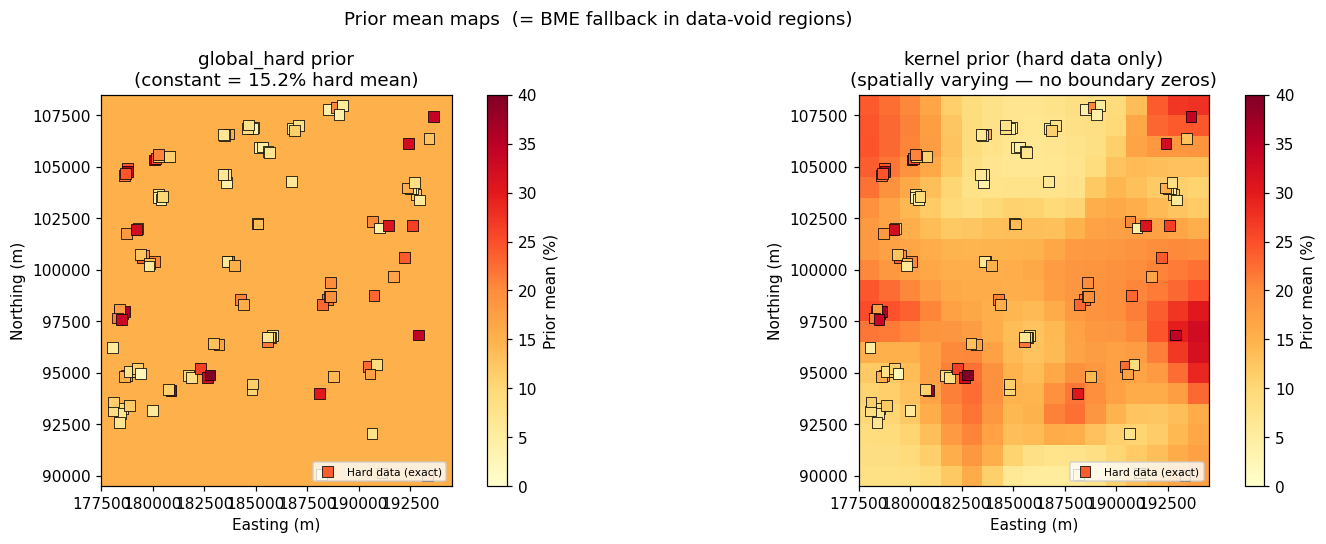

In [9]:
from stamps.bme.BMEprobaEstimations import BMEpriorMean

zh2d = sand.reshape(-1, 1)

# ── Step 1: build prior-mean arrays with different strategies ─────────────
# Shape of every output: (nk + nh + ns, 1)   [estimation grid, hard, soft]

# 'global_hard' — constant = hard data mean only (safe default with soft data)
order_gh = BMEpriorMean(ck, ch, zh2d, cs=cs, zs=zs_list,
                              method='global_hard')

# 'kernel' — Gaussian kernel smoother over hard data; spatially varying
# bandwidth auto-selected as max(1.5 × median_NN, 10 % of study extent)
# cv_bandwidth=True → select bandwidth by cross-validation
order_k  = BMEpriorMean(ck, ch, zh2d, cs=cs, zs=zs_list,
                              method='kernel', bandwidth=None, cv_bandwidth=True)

print('Prior mean statistics at estimation grid nodes (ck):')
print(f"  global_hard : {order_gh[:len(ck), 0].min():.2f} – {order_gh[:len(ck), 0].max():.2f}%"
      f"  (constant = hard-data mean)")
print(f"  kernel      : {order_k[:len(ck), 0].min():.2f} – {order_k[:len(ck), 0].max():.2f}%"
      f"  (spatially varying)")
print(f"\nHard data mean : {sand.mean():.2f}%  |  Soft midpoint mean : 18.30%")
print("=> 'global_hard' uses hard mean only, avoiding the soft-data upward bias")

# ── Step 2: visualise the prior maps themselves ────────────────────────────
# These maps show what BME *falls back to* in data-void regions.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prior_vlo, prior_vhi = 0.0, 40.0

plot_map(axes[0], ck, order_gh[:len(ck), 0],
         f"global_hard prior\n(constant = {sand.mean():.1f}% hard mean)",
         n_e, n_n, ch_data=ch, data_vals=sand,
         vmin=prior_vlo, vmax=prior_vhi, cbar_label='Prior mean (%)')

plot_map(axes[1], ck, order_k[:len(ck), 0],
         'kernel prior (hard data only)\n(spatially varying — no boundary zeros)',
         n_e, n_n, ch_data=ch, data_vals=sand,
         vmin=prior_vlo, vmax=prior_vhi, cbar_label='Prior mean (%)')

plt.suptitle('Prior mean maps  (= BME fallback in data-void regions)', fontsize=12)
plt.tight_layout()
plt.show()

# # Verify: no zero values at the map boundaries
# # order_k has shape (nk + nh + ns, 1); the first nk rows correspond to ck.
# order_k_at_ck = order_k[:len(ck), 0]   # (nk,) — estimation grid only
# boundary_mask = (
#     (ck[:, 0] == ck[:, 0].min()) | (ck[:, 0] == ck[:, 0].max()) |
#     (ck[:, 1] == ck[:, 1].min()) | (ck[:, 1] == ck[:, 1].max())
# )
# n_boundary = boundary_mask.sum()
# n_zeros_boundary = (order_k_at_ck[boundary_mask] < 1.0).sum()
# print(f"\nBoundary check: {n_zeros_boundary} / {n_boundary} boundary nodes have prior < 1%"
#       f"  (should be 0)")

### 5.5 Comparing prior choices on the BME estimate

We now run `BMEPosteriorMoments` four times — once per prior strategy — with identical neighbourhood parameters.  The difference between the resulting maps reveals how the prior choice propagates into the final estimate, especially at the map boundaries where data are sparse.

In [10]:
# ── Run BME with four different order / prior choices ──────────────────────

print('Running BME  order=np.nan  (zero prior — collapses at boundaries)...')
res_zero = BMEPosteriorMoments(
    ck, ch=ch, cs=cs, zh=zh2d, zs=zs_list,
    covmodel=covmodel, covparam=covparam,
    order=np.nan,                         # <-- zero prior (Simple-Kriging-like)
    nhmax=nhmax, nsmax=nsmax, dmax=np.array([[dmax]]),
    options=bme_opts,
)

print('Running BME  order=0  (global mean, hard + soft — biased at boundaries)...')
res_global = BMEPosteriorMoments(
    ck, ch=ch, cs=cs, zh=zh2d, zs=zs_list,
    covmodel=covmodel, covparam=covparam,
    order=0,                              # <-- global mean (hard + soft)
    nhmax=nhmax, nsmax=nsmax, dmax=np.array([[dmax]]),
    options=bme_opts,
)

print('Running BME  order=order_gh  (global_hard — hard mean only)...')
res_gh = BMEPosteriorMoments(
    ck, ch=ch, cs=cs, zh=zh2d, zs=zs_list,
    covmodel=covmodel, covparam=covparam,
    order=order_gh,                       # <-- constant = hard data mean
    nhmax=nhmax, nsmax=nsmax, dmax=np.array([[dmax]]),
    options=bme_opts,
)

print('Running BME  order=order_k  (kernel — spatially varying)...')
res_local = BMEPosteriorMoments(
    ck, ch=ch, cs=cs, zh=zh2d, zs=zs_list,
    covmodel=covmodel, covparam=covparam,
    order=order_k,                        # <-- kernel-smoothed hard data
    nhmax=nhmax, nsmax=nsmax, dmax=np.array([[dmax]]),
    options=bme_opts,
)

print('\n── Summary of BME map-mean across all 323 grid nodes ──')
print(f"  order=np.nan  (zero)        : {np.nanmean(res_zero[:, 0]):.2f}%"
      f"  ← collapses to 0 at boundaries")
print(f"  order=0       (hard+soft)   : {np.nanmean(res_global[:, 0]):.2f}%"
      f"  ← inflated by soft midpoints")
print(f"  order=order_gh (global_hard): {np.nanmean(res_gh[:, 0]):.2f}%"
      f"  ← unbiased constant fallback")
print(f"  order=order_k  (kernel)     : {np.nanmean(res_local[:, 0]):.2f}%"
      f"  ← spatially adaptive")

Running BME  order=np.nan  (zero prior — collapses at boundaries)...
preparing...done
[STARBME] BME estimation: nk=323, nh=118, ns=323, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


323 / 323
[STARBME] BME estimation completed in 3.5s (0.011s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.03664, max=0.2145; rel_err  median=0.57%, max=9.08% (323 of 323 points had QMC error info)
Running BME  order=0  (global mean, hard + soft — biased at boundaries)...
preparing...done
[STARBME] BME estimation: nk=323, nh=118, ns=323, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


323 / 323
[STARBME] BME estimation completed in 3.4s (0.010s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.07353, max=0.1935; rel_err  median=0.47%, max=1.11% (323 of 323 points had QMC error info)
Running BME  order=order_gh  (global_hard — hard mean only)...
preparing...done
[STARBME] BME estimation: nk=323, nh=118, ns=323, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


323 / 323
[STARBME] BME estimation completed in 3.3s (0.010s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.06764, max=0.1882; rel_err  median=0.45%, max=1.09% (323 of 323 points had QMC error info)
Running BME  order=order_k  (kernel — spatially varying)...
preparing...done
[STARBME] BME estimation: nk=323, nh=118, ns=323, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


323 / 323
[STARBME] BME estimation completed in 3.5s (0.011s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.06728, max=0.2251; rel_err  median=0.47%, max=1.04% (323 of 323 points had QMC error info)

── Summary of BME map-mean across all 323 grid nodes ──
  order=np.nan  (zero)        : 8.19%  ← collapses to 0 at boundaries
  order=0       (hard+soft)   : 16.45%  ← inflated by soft midpoints
  order=order_gh (global_hard): 15.52%  ← unbiased constant fallback
  order=order_k  (kernel)     : 15.73%  ← spatially adaptive


/var/folders/lm/y022zy7147q8x2k1bjrct88w0000gn/T/ipykernel_73503/3797748562.py:27: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/hdragon689/miniforge3/envs/bme/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


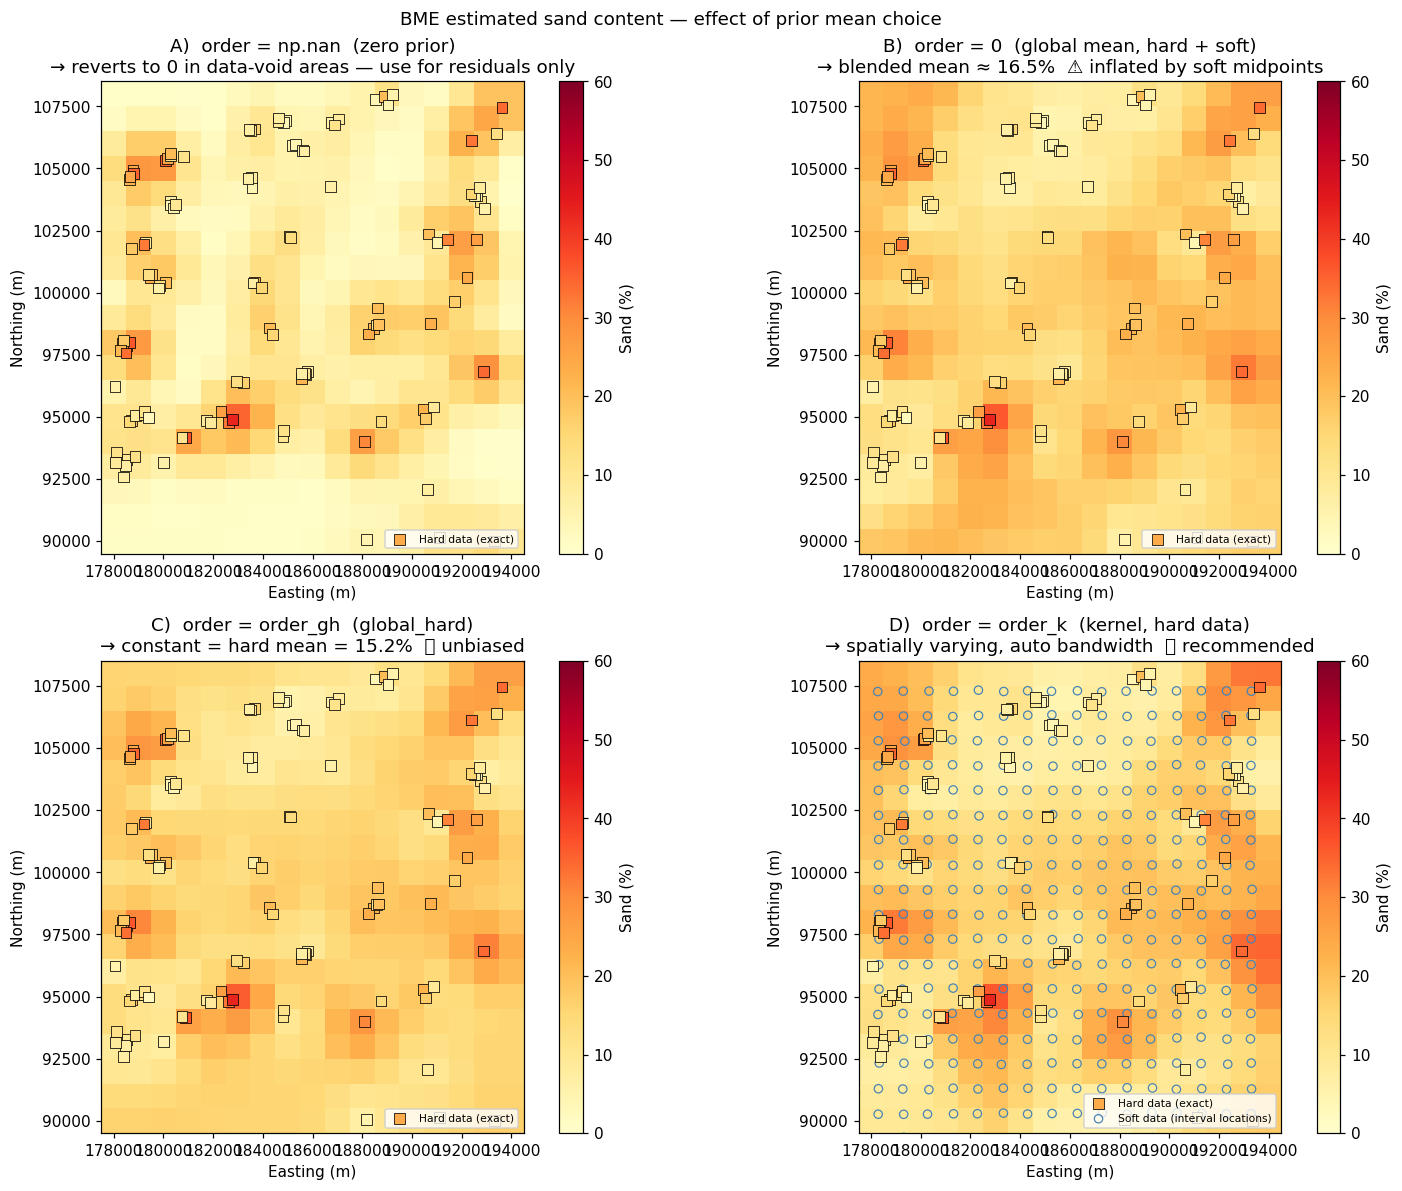

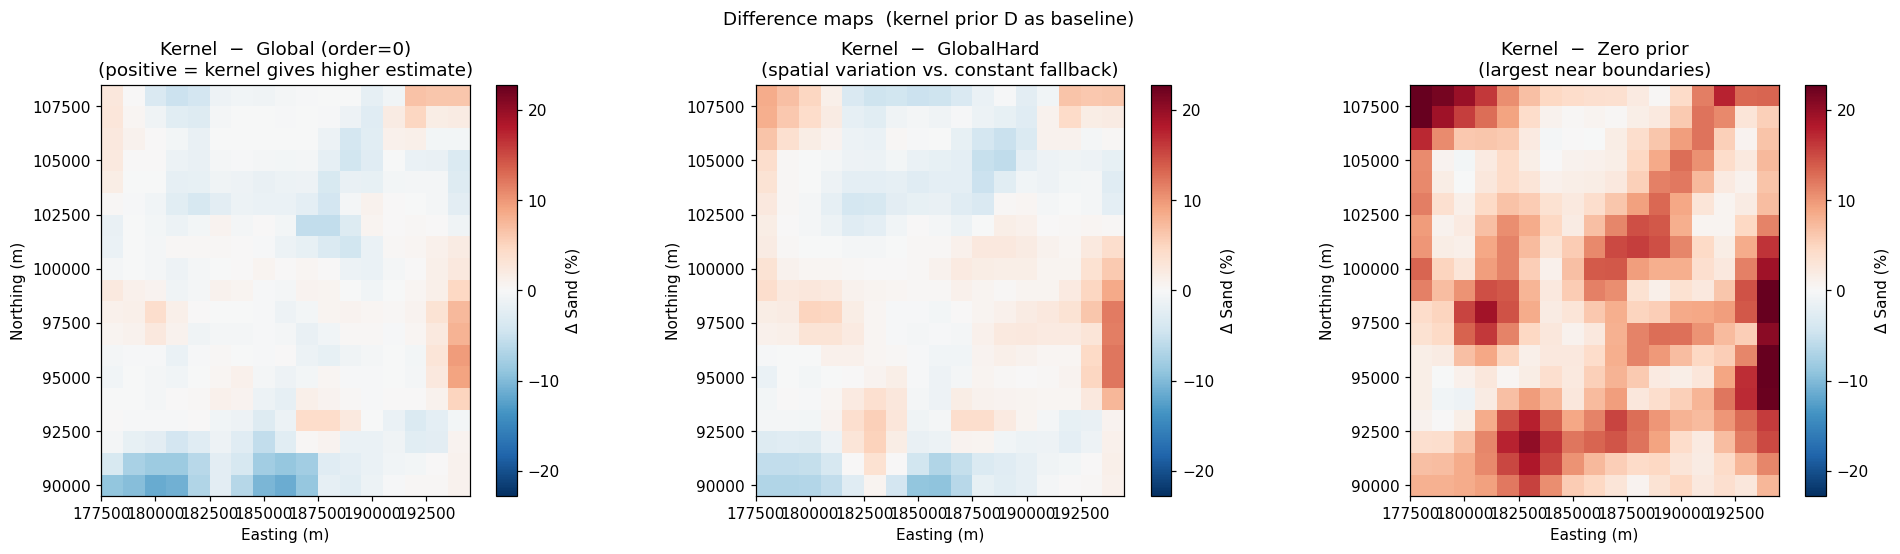

RMSD relative to kernel prior (D):
  B  vs D  (global order=0)  : RMSD = 2.820%  ← soft-data inflation
  C  vs D  (global_hard)     : RMSD = 3.035%  ← spatial vs. constant prior
  A  vs D  (zero prior)      : RMSD = 9.366%  ← largest, especially at map edges

Take-away:
  • order=np.nan  →  Wrong for raw measurements; severe boundary collapse.
  • order=0       →  Simple but biased upward when soft midpoints ≠ hard mean.
  • order_gh (global_hard) →  Safe, unbiased constant; best simple fix.
  • order_k  (kernel)      →  Spatially adaptive; recommended for non-stationary fields.


In [11]:
# ── 2×2 grid: BME mean maps for each prior choice ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
vlo, vhi = 0.0, 60.0

plot_map(axes[0, 0], ck, res_zero[:, 0],
         'A)  order = np.nan  (zero prior)\n'
         '→ reverts to 0 in data-void areas — use for residuals only',
         n_e, n_n, ch_data=ch, data_vals=sand, vmin=vlo, vmax=vhi, cbar_label='Sand (%)')

plot_map(axes[0, 1], ck, res_global[:, 0],
         'B)  order = 0  (global mean, hard + soft)\n'
         f'→ blended mean ≈ {np.nanmean(res_global[:, 0]):.1f}%  ⚠ inflated by soft midpoints',
         n_e, n_n, ch_data=ch, data_vals=sand, vmin=vlo, vmax=vhi, cbar_label='Sand (%)')

plot_map(axes[1, 0], ck, res_gh[:, 0],
         'C)  order = order_gh  (global_hard)\n'
         f'→ constant = hard mean = {sand.mean():.1f}%  ✅ unbiased',
         n_e, n_n, ch_data=ch, data_vals=sand, vmin=vlo, vmax=vhi, cbar_label='Sand (%)')

plot_map(axes[1, 1], ck, res_local[:, 0],
         'D)  order = order_k  (kernel, hard data)\n'
         '→ spatially varying, auto bandwidth  ✅ recommended',
         n_e, n_n, ch_data=ch, data_vals=sand, cs_data=cs,
         vmin=vlo, vmax=vhi, cbar_label='Sand (%)')

plt.suptitle('BME estimated sand content — effect of prior mean choice', fontsize=12)
plt.tight_layout()
plt.show()

# ── Difference maps (kernel prior as reference baseline) ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
diff_gl = res_local[:, 0] - res_global[:, 0]   # kernel vs. order=0
diff_gh = res_local[:, 0] - res_gh[:, 0]       # kernel vs. global_hard
diff_zr = res_local[:, 0] - res_zero[:, 0]     # kernel vs. zero

lim = np.nanpercentile(np.abs(diff_zr), 99)

plot_map(axes[0], ck, diff_gl,
         'Kernel  −  Global (order=0)\n(positive = kernel gives higher estimate)',
         n_e, n_n, cmap='RdBu_r', vmin=-lim, vmax=lim, cbar_label='Δ Sand (%)')
plot_map(axes[1], ck, diff_gh,
         'Kernel  −  GlobalHard\n(spatial variation vs. constant fallback)',
         n_e, n_n, cmap='RdBu_r', vmin=-lim, vmax=lim, cbar_label='Δ Sand (%)')
plot_map(axes[2], ck, diff_zr,
         'Kernel  −  Zero prior\n(largest near boundaries)',
         n_e, n_n, cmap='RdBu_r', vmin=-lim, vmax=lim, cbar_label='Δ Sand (%)')

plt.suptitle('Difference maps  (kernel prior D as baseline)', fontsize=12)
plt.tight_layout()
plt.show()

# ── Quantitative summary ───────────────────────────────────────────────────
print('RMSD relative to kernel prior (D):')
print(f'  B  vs D  (global order=0)  : RMSD = {np.sqrt(np.nanmean(diff_gl**2)):.3f}%'
      f'  ← soft-data inflation')
print(f'  C  vs D  (global_hard)     : RMSD = {np.sqrt(np.nanmean(diff_gh**2)):.3f}%'
      f'  ← spatial vs. constant prior')
print(f'  A  vs D  (zero prior)      : RMSD = {np.sqrt(np.nanmean(diff_zr**2)):.3f}%'
      f'  ← largest, especially at map edges')
print()
print('Take-away:')
print('  • order=np.nan  →  Wrong for raw measurements; severe boundary collapse.')
print('  • order=0       →  Simple but biased upward when soft midpoints ≠ hard mean.')
print('  • order_gh (global_hard) →  Safe, unbiased constant; best simple fix.')
print('  • order_k  (kernel)      →  Spatially adaptive; recommended for non-stationary fields.')

## 6. Effect of soft data neighbourhood size (`nsmax`)

The `nsmax` parameter controls how many soft data points are used per estimation node.  Using too few may miss relevant interval measurements; too many may slow down computation and can trigger more QMC fallbacks.


preparing...done
[STARBME] BME estimation: nk=323, nh=118, ns=323, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


323 / 323
[STARBME] BME estimation completed in 1.7s (0.005s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.03647, max=0.2024; rel_err  median=0.23%, max=0.88% (323 of 323 points had QMC error info)
preparing...done
[STARBME] BME estimation: nk=323, nh=118, ns=323, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


323 / 323
[STARBME] BME estimation completed in 3.4s (0.011s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.07353, max=0.1935; rel_err  median=0.47%, max=1.11% (323 of 323 points had QMC error info)
preparing...done
[STARBME] BME estimation: nk=323, nh=118, ns=323, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


323 / 323
[STARBME] BME estimation completed in 6.8s (0.021s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.1282, max=0.3764; rel_err  median=0.83%, max=1.57% (323 of 323 points had QMC error info)


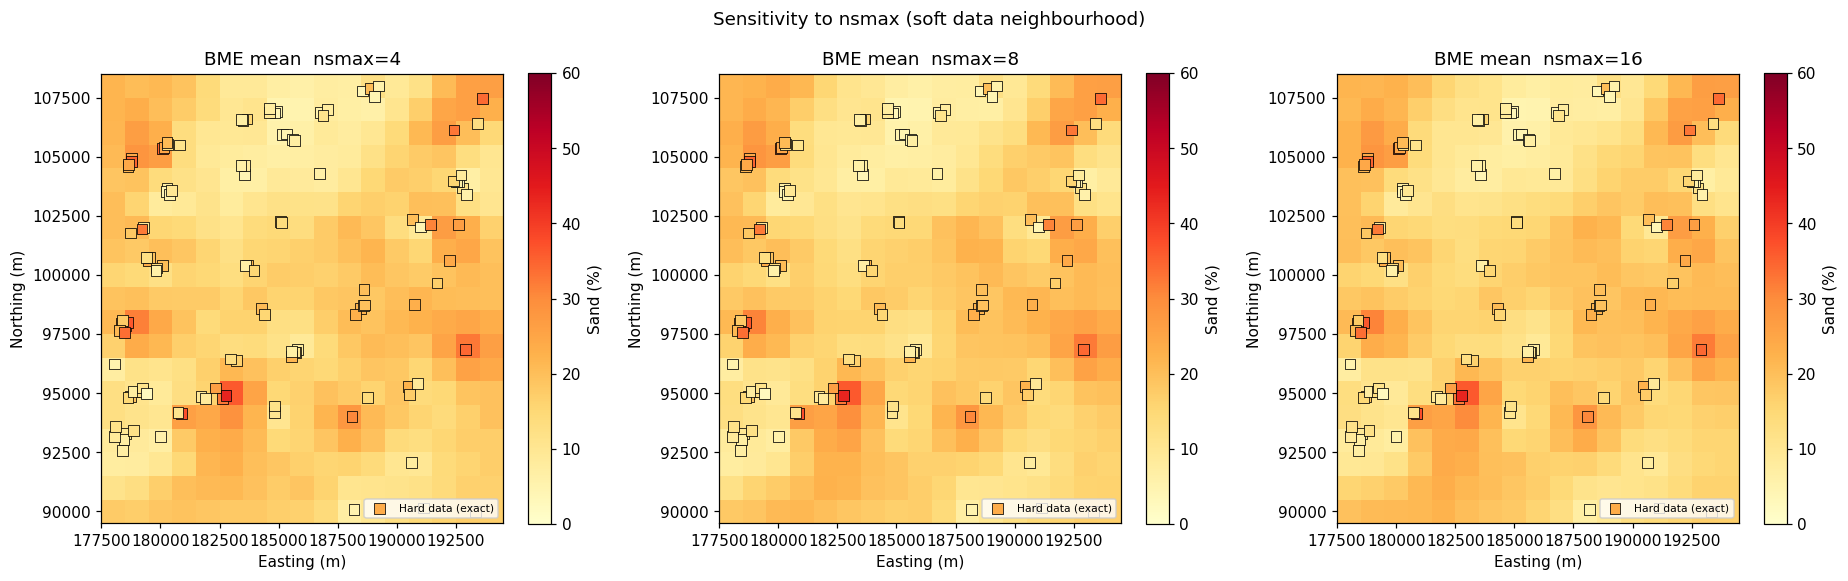

In [12]:
nsmax_vals = [4, 8, 16]
fig, axes  = plt.subplots(1, 3, figsize=(17, 5))

for ax, ns in zip(axes, nsmax_vals):
    res = BMEPosteriorMoments(
        ck,
        ch=ch, cs=cs,
        zh=sand.reshape(-1, 1),
        zs=zs_list,
        covmodel=covmodel,
        covparam=covparam,
        order=0, #np.nan
        nhmax=nhmax, nsmax=ns, dmax=np.array([[dmax]]),
        options=bme_opts,
    )
    plot_map(ax, ck, res[:, 0], f'BME mean  nsmax={ns}', n_e, n_n,
             ch_data=ch, data_vals=sand,
             vmin=vlo, vmax=vhi, cbar_label='Sand (%)')

plt.suptitle('Sensitivity to nsmax (soft data neighbourhood)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


In [13]:
# Save BME results for Tutorial 06
import pickle

bme05_results = {
    'zk_bme_mean': zk_bme_mean,
    'zk_bme_var':  zk_bme_var,
}
save_path = os.path.join(DATA_DIR, 'tutorial05_bme.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(bme05_results, f)
print('Saved:', save_path)


Saved: /Users/hdragon689/Documents/MyDoc_iCloud/packages/stamps/stamps_v3/tutorials/data/tutorial05_bme.pkl


## 7. Summary

| Step | stamps_v3 function | Key argument |
|---|---|---|
| Encode intervals | `probaUniform(zlow, zup)` | Returns `(softpdftype, nl, limi, probdens)` |
| Soft data statistics | `proba2stat(...)` | Compute mean and variance of each soft PDF |
| Build prior mean | `BMEpriorMean(ck, ch, zh, ...)` | `method='kernel'` or `'global_hard'` |
| BME estimation | `BMEPosteriorMoments(..., order=...)` | Pass result of `BMEpriorMean` as `order` |

**Key insights:**
- Interval soft data carry less information than hard data but more than knowing nothing.
- BME reduces estimation variance compared to kriging wherever soft data exist.
- **The `order` parameter is critical.** `order=0` blends hard and soft means and can inflate boundaries when soft midpoints differ from the hard data mean.  Prefer `method='global_hard'` or `method='kernel'` via `BMEpriorMean`.
- The kernel prior auto-bandwidth uses `max(1.5 × median_NN, 0.1 × extent)` — robust to clustered sampling and prevents near-zero values at map boundaries.

**Next:** Tutorial 06 - BME with full probabilistic soft data (arbitrary PDFs).
